In [7]:
from datasets import load_dataset
from pathlib import Path
from collections import Counter
import pandas as pd

print("DocuMind dataset inspection started")

DocuMind dataset inspection started


In [8]:
enron = load_dataset(
    "corbt/enron-emails",
    split="train",
    streaming=True
)

print(enron)

IterableDataset({
    features: ['message_id', 'subject', 'from', 'to', 'cc', 'bcc', 'date', 'body', 'file_name'],
    num_shards: 3
})


In [9]:
email = next(iter(enron))

print("Subject:", email["subject"])
print("From:", email["from"])
print("To:", email["to"])
print("Date:", email["date"])
print("\nBody:\n", email["body"][:2000])

Subject: 
From: phillip.allen@enron.com
To: ['tim.belden@enron.com']
Date: 2001-05-14 23:39:00+00:00

Body:
 Here is our forecast

 


In [10]:
email = next(iter(enron))

print("Subject:", email["subject"])
print("From:", email["from"])
print("To:", email["to"])
print("Date:", email["date"])
print("\nBody:\n", email["body"][:2000])

Subject: 
From: phillip.allen@enron.com
To: ['tim.belden@enron.com']
Date: 2001-05-14 23:39:00+00:00

Body:
 Here is our forecast

 


In [11]:
count = 0

for email in enron:
    body = email["body"].strip()

    if len(body) >= 500:
        print("Subject:", email["subject"])
        print("From:", email["from"])
        print("To:", email["to"])
        print("Body:\n", body[:1500])
        print("\n" + "=" * 80 + "\n")

        count += 1

        if count == 3:
            break

Subject: Re:
From: phillip.allen@enron.com
To: ['john.lavorato@enron.com']
Body:
 Traveling to have a business meeting takes the fun out of the trip.  Especially if you have to prepare a presentation.  I would suggest holding the business plan meetings here then take a trip without any formal business meetings.  I would even try and get some honest opinions on whether a trip is even desired or necessary.

As far as the business meetings, I think it would be more productive to try and stimulate discussions across the different groups about what is working and what is not.  Too often the presenter speaks and the others are quiet just waiting for their turn.   The meetings might be better if held in a round table discussion format.  

My suggestion for where to go is Austin.  Play golf and rent a ski boat and jet ski's.  Flying somewhere takes too much time.


Subject: FW: fixed forward or other Collar floor gas price terms
From: phillip.allen@enron.com
To: ['zimam@enron.com']
Body:
 ----

In [12]:
lengths = []

for i, email in enumerate(enron):
    body = email["body"].strip()

    if len(body) >= 100:
        lengths.append(len(body))

    if i >= 10000:
        break

print("Emails inspected:", len(lengths))
print("Minimum length:", min(lengths))
print("Maximum length:", max(lengths))
print("Average length:", sum(lengths) / len(lengths))

Emails inspected: 8670
Minimum length: 100
Maximum length: 122534
Average length: 1920.7447520184544


In [13]:
print(">= 100 chars:", sum(length >= 100 for length in lengths))
print(">= 200 chars:", sum(length >= 200 for length in lengths))
print(">= 500 chars:", sum(length >= 500 for length in lengths))
print(">= 1000 chars:", sum(length >= 1000 for length in lengths))

>= 100 chars: 8670
>= 200 chars: 7734
>= 500 chars: 5442
>= 1000 chars: 3540


In [14]:
cuad = load_dataset(
    "theatticusproject/cuad",
    split="train",
    streaming=True
)

print(cuad)

Resolving data files:   0%|          | 0/714 [00:00<?, ?it/s]

IterableDataset({
    features: ['pdf'],
    num_shards: 1
})


In [15]:
from huggingface_hub import snapshot_download

In [16]:
cuad_path = snapshot_download(
    repo_id="theatticusproject/cuad",
    repo_type="dataset",
    allow_patterns=["CUAD_v1/full_contract_txt/**"]
)

print("CUAD downloaded to:", cuad_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 200 files:   0%|          | 0/200 [00:00<?, ?it/s]

CUAD downloaded to: C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1


In [17]:
contract_files = list(Path(cuad_path).rglob("*.txt"))

print("Contract TXT files found:", len(contract_files))

for file in contract_files[:5]:
    print(file)

Contract TXT files found: 200
C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1\CUAD_v1\full_contract_txt\Part_I\ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEMENT.txt
C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1\CUAD_v1\full_contract_txt\Part_I\ACCURAYINC_09_01_2010-EX-10.31-DISTRIBUTOR AGREEMENT.txt
C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1\CUAD_v1\full_contract_txt\Part_I\ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT.txt
C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1\CUAD_v1\full_contract_txt\Part_I\AimmuneTherapeuticsInc_20200205_8-K_EX-10.3_11967170_EX-10.3_Development Agreement.txt
C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5

In [18]:
contracts_dir = Path(cuad_path) / "CUAD_v1" / "full_contract_txt"

for folder in contracts_dir.iterdir():
    if folder.is_dir():
        print(folder.name)

Part_I
Part_II


In [19]:
part1_files = list((contracts_dir / "Part_I").glob("*.txt"))
part2_files = list((contracts_dir / "Part_II").glob("*.txt"))

print("Part I:", len(part1_files))
print("Part II:", len(part2_files))
print("Total:", len(part1_files) + len(part2_files))

Part I: 100
Part II: 100
Total: 200


In [20]:
cuad_path = snapshot_download(
    repo_id="theatticusproject/cuad",
    repo_type="dataset",
    allow_patterns=["CUAD_v1/full_contract_txt/**"],
    force_download=True
)

print(cuad_path)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 200 files:   0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1


In [21]:
contract_files = list(
    (Path(cuad_path) / "CUAD_v1" / "full_contract_txt").rglob("*.txt")
)

print("Contract TXT files:", len(contract_files))

Contract TXT files: 200


In [22]:
from huggingface_hub import hf_hub_download
import json

cuad_json = hf_hub_download(
    repo_id="theatticusproject/cuad",
    repo_type="dataset",
    filename="CUAD_v1/CUAD_v1.json"
)

print("Downloaded:", cuad_json)

Downloaded: C:\Users\sudee\.cache\huggingface\hub\datasets--theatticusproject--cuad\snapshots\a3c393f5d103fd0c516374e4fdff676c8176dcb1\CUAD_v1\CUAD_v1.json


In [23]:
with open(cuad_json, "r", encoding="utf-8") as f:
    cuad_data = json.load(f)

print("Contracts:", len(cuad_data["data"]))

Contracts: 510


In [24]:
contract = cuad_data["data"][0]

print(contract.keys())
print("Title:", contract["title"])
print("Number of paragraphs:", len(contract["paragraphs"]))

dict_keys(['title', 'paragraphs'])
Title: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Number of paragraphs: 1


In [25]:
text = "\n".join(
    paragraph["context"]
    for paragraph in contract["paragraphs"]
)

print(text[:5000])

EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

                                    RECITALS

         A. The  Company's  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an "Energy  Saver"  which may be improved  or  otherwise  changed  from its present composition (the "Products").  The Company may engage in the business of selling other  products  or  other  devices  other  than  the  Products,  which  will be considered  Products if Distributor  exercises its options pursuant to Section 7 hereof.

         B. Representations.  As an inducement to the Company to enter into this Agreement,  the  Distributor  has  represented  that  it has or  will  have  the facil

In [26]:
contract_texts = []

for item in cuad_data["data"]:
    text = "\n".join(
        paragraph["context"]
        for paragraph in item["paragraphs"]
    ).strip()
    
    contract_texts.append(text)

lengths = [len(text) for text in contract_texts]

print("Contracts:", len(contract_texts))
print("Shortest:", min(lengths), "characters")
print("Longest:", max(lengths), "characters")
print("Average:", sum(lengths) / len(lengths), "characters")

Contracts: 510
Shortest: 645 characters
Longest: 338211 characters
Average: 52563.00588235294 characters


In [27]:
invoice_ds = load_dataset(
    "amaye15/invoices-google-ocr",
    split="train",
    streaming=True
)

print(invoice_ds)

IterableDataset({
    features: ['pixel_values', 'label', 'ocr'],
    num_shards: 6
})


In [28]:
invoice = next(iter(invoice_ds))

print("Label:", invoice["label"])
print("\nOCR text:")
print(invoice["ocr"][:3000])

Label: 1

OCR text:
[{'bounding box': {'vertex 0': {'x': 12, 'y': 27}, 'vertex 1': {'x': 566, 'y': 27}, 'vertex 2': {'x': 566, 'y': 793}, 'vertex 3': {'x': 12, 'y': 793}}, 'text': 'White and Sons\nEmail:cpetersen@example.com\nwww.WhiteandSons.org\nINVOICE\nZZZ\nBuyer: Thomas Neal\n853 Barnes Street Apt. 985\nLake Robert, NY 19313 US\nTel:+(428)870-5886\nEmail:dcarey@example.com\nSite:http://www.duran.org/\nInvoice number 9Y4M8d-752\nDate: 09-Aug-2007\nDue Date: 08-Aug-2010\nITEMS\nWind be why.\nQUANTITY\nPRICE\n6.00\n$93.70\nDesign actually need.\n5.00\n$30.60\nThat population.\n3.00\n$3.67\nSUB TOTAL: 726.21 EUR\nGST(9%): 65.36\nTOTAL: 740.88 EUR'}, {'bounding box': {'vertex 0': {'x': 23, 'y': 27}, 'vertex 1': {'x': 56, 'y': 27}, 'vertex 2': {'x': 56, 'y': 37}, 'vertex 3': {'x': 23, 'y': 37}}, 'text': 'White'}, {'bounding box': {'vertex 0': {'x': 58, 'y': 27}, 'vertex 1': {'x': 80, 'y': 27}, 'vertex 2': {'x': 80, 'y': 37}, 'vertex 3': {'x': 58, 'y': 37}}, 'text': 'and'}, {'bounding bo

In [25]:
invoice_text_ds = invoice_ds.remove_columns(["pixel_values"])

In [26]:
invoice = next(iter(invoice_text_ds))

print("Label:", invoice["label"])
print("\nOCR text:")
print(invoice["ocr"][:3000])

ImportError: To support decoding images, please install 'Pillow'.

In [29]:
invoice_text_ds = load_dataset(
    "amaye15/invoices-google-ocr",
    split="train",
    streaming=True
).select_columns(["label", "ocr"])

print(invoice_text_ds)

IterableDataset({
    features: ['label', 'ocr'],
    num_shards: 6
})


In [30]:
invoice = next(iter(invoice_text_ds))

print("Label:", invoice["label"])
print("\nOCR text:")
print(invoice["ocr"][:3000])

Label: 1

OCR text:
[{'bounding box': {'vertex 0': {'x': 12, 'y': 27}, 'vertex 1': {'x': 566, 'y': 27}, 'vertex 2': {'x': 566, 'y': 793}, 'vertex 3': {'x': 12, 'y': 793}}, 'text': 'White and Sons\nEmail:cpetersen@example.com\nwww.WhiteandSons.org\nINVOICE\nZZZ\nBuyer: Thomas Neal\n853 Barnes Street Apt. 985\nLake Robert, NY 19313 US\nTel:+(428)870-5886\nEmail:dcarey@example.com\nSite:http://www.duran.org/\nInvoice number 9Y4M8d-752\nDate: 09-Aug-2007\nDue Date: 08-Aug-2010\nITEMS\nWind be why.\nQUANTITY\nPRICE\n6.00\n$93.70\nDesign actually need.\n5.00\n$30.60\nThat population.\n3.00\n$3.67\nSUB TOTAL: 726.21 EUR\nGST(9%): 65.36\nTOTAL: 740.88 EUR'}, {'bounding box': {'vertex 0': {'x': 23, 'y': 27}, 'vertex 1': {'x': 56, 'y': 27}, 'vertex 2': {'x': 56, 'y': 37}, 'vertex 3': {'x': 23, 'y': 37}}, 'text': 'White'}, {'bounding box': {'vertex 0': {'x': 58, 'y': 27}, 'vertex 1': {'x': 80, 'y': 27}, 'vertex 2': {'x': 80, 'y': 37}, 'vertex 3': {'x': 58, 'y': 37}}, 'text': 'and'}, {'bounding bo

In [31]:
invoice = next(iter(invoice_text_ds))

print("Label:", invoice["label"])
print("OCR type:", type(invoice["ocr"]))
print("OCR preview:")
print(str(invoice["ocr"])[:3000])

Label: 1
OCR type: <class 'list'>
OCR preview:
[{'bounding box': {'vertex 0': {'x': 12, 'y': 27}, 'vertex 1': {'x': 566, 'y': 27}, 'vertex 2': {'x': 566, 'y': 793}, 'vertex 3': {'x': 12, 'y': 793}}, 'text': 'White and Sons\nEmail:cpetersen@example.com\nwww.WhiteandSons.org\nINVOICE\nZZZ\nBuyer: Thomas Neal\n853 Barnes Street Apt. 985\nLake Robert, NY 19313 US\nTel:+(428)870-5886\nEmail:dcarey@example.com\nSite:http://www.duran.org/\nInvoice number 9Y4M8d-752\nDate: 09-Aug-2007\nDue Date: 08-Aug-2010\nITEMS\nWind be why.\nQUANTITY\nPRICE\n6.00\n$93.70\nDesign actually need.\n5.00\n$30.60\nThat population.\n3.00\n$3.67\nSUB TOTAL: 726.21 EUR\nGST(9%): 65.36\nTOTAL: 740.88 EUR'}, {'bounding box': {'vertex 0': {'x': 23, 'y': 27}, 'vertex 1': {'x': 56, 'y': 27}, 'vertex 2': {'x': 56, 'y': 37}, 'vertex 3': {'x': 23, 'y': 37}}, 'text': 'White'}, {'bounding box': {'vertex 0': {'x': 58, 'y': 27}, 'vertex 1': {'x': 80, 'y': 27}, 'vertex 2': {'x': 80, 'y': 37}, 'vertex 3': {'x': 58, 'y': 37}}, 't

In [32]:
print(invoice_text_ds.features["label"])

invoice_text = "\n".join(
    item["text"]
    for item in invoice["ocr"]
    if "text" in item
)

print(invoice_text[:3000])

ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object'])
White and Sons
Email:cpetersen@example.com
www.WhiteandSons.org
INVOICE
ZZZ
Buyer: Thomas Neal
853 Barnes Street Apt. 985
Lake Robert, NY 19313 US
Tel:+(428)870-5886
Email:dcarey@example.com
Site:http://www.duran.org/
Invoice number 9Y4M8d-752
Date: 09-Aug-2007
Due Date: 08-Aug-2010
ITEMS
Wind be why.
QUANTITY
PRICE
6.00
$93.70
Design actually need.
5.00
$30.60
That population.
3.00
$3.67
SUB TOTAL: 726.21 EUR
GST(9%): 65.36
TOTAL: 740.88 EUR
White
and
Sons
Email
:
cpetersen@example.com
www.WhiteandSons.org
INVOICE
ZZZ
Buyer
:
Thomas
Neal
853
Barnes
Street
Apt
.
985
Lake
Robert
,
NY
19313
US
Tel
:
+
(
428
)
870-5886
Email
:
dcarey@example.com
Site
:
http
:
//www.duran.org/
Invoice
number
9Y4M8d
-
752
Date
:
09
-
Aug
-
2007
Due
Date
:
08
-
Aug
-
2010
ITEMS
Wind
be
why
.
QUANTITY
PRICE
6.00
$
93.70
Design
actually
need
.
5.00
$
30.60
That
population
.
3.00
$
3.67
SUB
TOTAL
:
726.21
EUR
GST
(
9
%
)
:
65.36
TOTAL
:

In [33]:
for i, item in enumerate(invoice["ocr"][:10]):
    text = item.get("text", "")
    print(f"{i}: {len(text)} chars | {text[:100]!r}")

0: 446 chars | 'White and Sons\nEmail:cpetersen@example.com\nwww.WhiteandSons.org\nINVOICE\nZZZ\nBuyer: Thomas Neal\n853 B'
1: 5 chars | 'White'
2: 3 chars | 'and'
3: 4 chars | 'Sons'
4: 5 chars | 'Email'
5: 1 chars | ':'
6: 21 chars | 'cpetersen@example.com'
7: 20 chars | 'www.WhiteandSons.org'
8: 7 chars | 'INVOICE'
9: 3 chars | 'ZZZ'


In [34]:
invoice_text = invoice["ocr"][0]["text"]

print(invoice_text)


White and Sons
Email:cpetersen@example.com
www.WhiteandSons.org
INVOICE
ZZZ
Buyer: Thomas Neal
853 Barnes Street Apt. 985
Lake Robert, NY 19313 US
Tel:+(428)870-5886
Email:dcarey@example.com
Site:http://www.duran.org/
Invoice number 9Y4M8d-752
Date: 09-Aug-2007
Due Date: 08-Aug-2010
ITEMS
Wind be why.
QUANTITY
PRICE
6.00
$93.70
Design actually need.
5.00
$30.60
That population.
3.00
$3.67
SUB TOTAL: 726.21 EUR
GST(9%): 65.36
TOTAL: 740.88 EUR


In [35]:
invoice_samples = []

for item in invoice_text_ds:
    if item["label"] == 1:
        invoice_samples.append(item["ocr"][0]["text"])

    if len(invoice_samples) == 100:
        break

print("Invoice samples collected:", len(invoice_samples))

Invoice samples collected: 100


In [36]:
for i in range(3):
    print(f"\n===== INVOICE {i + 1} =====\n")
    print(invoice_samples[i][:1500])


===== INVOICE 1 =====

White and Sons
Email:cpetersen@example.com
www.WhiteandSons.org
INVOICE
ZZZ
Buyer: Thomas Neal
853 Barnes Street Apt. 985
Lake Robert, NY 19313 US
Tel:+(428)870-5886
Email:dcarey@example.com
Site:http://www.duran.org/
Invoice number 9Y4M8d-752
Date: 09-Aug-2007
Due Date: 08-Aug-2010
ITEMS
Wind be why.
QUANTITY
PRICE
6.00
$93.70
Design actually need.
5.00
$30.60
That population.
3.00
$3.67
SUB TOTAL: 726.21 EUR
GST(9%): 65.36
TOTAL: 740.88 EUR

===== INVOICE 2 =====

SIMPDEHY
Montgomery, Harrison and Vaughan
Address:840 Anderson Locks
Mariatown, AL 01838 US
TAX INVOICE
Invoice number 4268-892
Invoice Date: 01-Feb-1999
Due Date: 11-Jan-2022
BALANCE DUE : 768.46 $
SHIP TO:
Kathy Grant
150 Perez Mount Apt. 136
Fitzpatrickburgh, MD 09463 US
Tel:+(107)976-0236
Email:mtaylor@example.org
Site:http://mcdaniel.biz/
ITEMS
QUANTITY
PRICE
Within guy.
Chance hotel television win.
4.00
$70.04
3.00
$16.43
Score yard suffer.
Hit professor total.
3.00
$61.53
3.00
$79.33
SUB TOTAL

In [37]:
from getpass import getpass

DOCILE_TOKEN = getpass("Enter your DocILE access token: ")

In [38]:
from getpass import getpass

DOCILE_TOKEN = getpass("Enter DocILE token: ")
print("Token received.")

Token received.


In [39]:
import requests

url = "https://raw.githubusercontent.com/rossumai/docile/main/download_dataset.sh"

response = requests.get(url, timeout=30)

print(response.status_code)
print(response.text[:5000])

200
#!/bin/bash

set -euo pipefail

UNLABELED_CHUNK_MAX=93

print_help() {
  echo "Usage:"
  echo "./download_dataset.sh SECRET_TOKEN DATASET TARGET_DIR [--unzip] [--without-pdfs]"
  echo
  echo "or to only show download urls:"
  echo "./download_dataset.sh SECRET_TOKEN DATASET --show-urls [--without-pdfs]"
  echo
  echo "Script to download the docile dataset. Uses curl to download the files and unzip to unzip"
  echo "them (when --unzip is used). Note: all datasets can be unzipped to the same TARGET_DIR."
  echo
  echo "To get the SECRET_TOKEN, follow the instructions at https://docile.rossum.ai"
  echo
  echo "Available DATASETs: labeled-trainval, synthetic, unlabeled"
  echo "For synthetic and unlabeled datasets you can also download chunks of 10000 documents:"
  echo "    Download stand-alone synthetic chunk (i is in 0..9):"
  echo "        ./download_dataset.sh SECRET_TOKEN synthetic-chunk-\${i} TARGET_DIR [--unzip]"
  echo "    To use unlabeled chunk(s) stand-alone you first need

In [40]:
import requests

url = f"https://docile-dataset-rossum.s3.eu-west-1.amazonaws.com/{DOCILE_TOKEN}/labeled-trainval.zip"

response = requests.head(url, timeout=30)

size_gb = int(response.headers.get("Content-Length", 0)) / (1024 ** 3)

print("HTTP status:", response.status_code)
print(f"Dataset size: {size_gb:.2f} GB")

HTTP status: 404
Dataset size: 0.00 GB


In [41]:
url = f"https://docile-dataset-rossum.s3.eu-west-1.amazonaws.com/{DOCILE_TOKEN}/annotated-trainval.zip"

response = requests.head(url, timeout=30)

print("HTTP status:", response.status_code)

if response.ok:
    size_gb = int(response.headers.get("Content-Length", 0)) / (1024 ** 3)
    print(f"Dataset size: {size_gb:.2f} GB")
else:
    print("Could not access the dataset.")

HTTP status: 200
Dataset size: 1.06 GB


In [42]:
from pathlib import Path
import requests
import zipfile

docile_dir = Path("../../data/docile")
docile_dir.mkdir(parents=True, exist_ok=True)

url = f"https://docile-dataset-rossum.s3.eu-west-1.amazonaws.com/{DOCILE_TOKEN}/annotated-trainval.zip"
zip_path = docile_dir / "annotated-trainval.zip"

print("Downloading DocILE...")
response = requests.get(url, stream=True, timeout=60)
response.raise_for_status()

with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print(f"Downloaded to: {zip_path}")

KeyboardInterrupt: 

In [41]:
from pathlib import Path

zip_path = Path("../../data/docile/annotated-trainval.zip")

if zip_path.exists():
    print(f"Partial file exists: {zip_path.stat().st_size / (1024**3):.2f} GB")
else:
    print("No download started yet.")

Partial file exists: 0.54 GB


In [42]:
from pathlib import Path
import requests

zip_path = Path("../../data/docile/annotated-trainval.zip")

url = f"https://docile-dataset-rossum.s3.eu-west-1.amazonaws.com/{DOCILE_TOKEN}/annotated-trainval.zip"

downloaded = zip_path.stat().st_size if zip_path.exists() else 0

headers = {
    "Range": f"bytes={downloaded}-"
}

print(f"Resuming from {downloaded / (1024**3):.2f} GB...")

with requests.get(
    url,
    headers=headers,
    stream=True,
    timeout=(30, 300)
) as response:

    print("HTTP status:", response.status_code)
    response.raise_for_status()

    with open(zip_path, "ab") as f:
        for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):
            if chunk:
                f.write(chunk)

print(
    f"Download size: {zip_path.stat().st_size / (1024**3):.2f} GB"
)

Resuming from 0.54 GB...
HTTP status: 206
Download size: 1.06 GB


In [43]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Files in archive:", len(files))

for file in files[:30]:
    print(file)

Files in archive: 17043
val.json
train.json
trainval.json
ocr/00134dd365a24343b35b78c6.json
pdfs/00134dd365a24343b35b78c6.pdf
annotations/00134dd365a24343b35b78c6.json
ocr/00136a27c7774c1e8dc6b2f2.json
pdfs/00136a27c7774c1e8dc6b2f2.pdf
annotations/00136a27c7774c1e8dc6b2f2.json
ocr/002e3cf97973428f905671b3.json
pdfs/002e3cf97973428f905671b3.pdf
annotations/002e3cf97973428f905671b3.json
ocr/002f9b82b74f4258b3b072d0.json
pdfs/002f9b82b74f4258b3b072d0.pdf
annotations/002f9b82b74f4258b3b072d0.json
ocr/003568b1286f4dab953fc2d5.json
pdfs/003568b1286f4dab953fc2d5.pdf
annotations/003568b1286f4dab953fc2d5.json
ocr/0039ed9f32974a90afb4f8f2.json
pdfs/0039ed9f32974a90afb4f8f2.pdf
annotations/0039ed9f32974a90afb4f8f2.json
ocr/003cc91637994b7d9566ac41.json
pdfs/003cc91637994b7d9566ac41.pdf
annotations/003cc91637994b7d9566ac41.json
ocr/00405d767fb1406180d05ef2.json
pdfs/00405d767fb1406180d05ef2.pdf
annotations/00405d767fb1406180d05ef2.json
ocr/004e76fe452448eebaadc53b.json
pdfs/004e76fe452448eebaadc53

In [44]:
import json
import zipfile

with zipfile.ZipFile(zip_path, "r") as z:
    train_meta = json.loads(z.read("train.json"))
    val_meta = json.loads(z.read("val.json"))

print("Train documents:", len(train_meta))
print("Validation documents:", len(val_meta))

print("\nTrain sample:")
print(train_meta[0])

Train documents: 5180
Validation documents: 500

Train sample:
00134dd365a24343b35b78c6


In [45]:
with zipfile.ZipFile(zip_path, "r") as z:
    sample_id = train_meta[0]
    
    annotation = json.loads(
        z.read(f"annotations/{sample_id}.json")
    )

print(annotation.keys())
print(annotation)

dict_keys(['field_extractions', 'line_item_extractions', 'line_item_headers', 'metadata'])
{'field_extractions': [{'bbox': [0.7825308989140187, 0.34950390316404, 0.8833072215750077, 0.36071127298046407], 'fieldtype': 'document_id', 'page': 0, 'text': '990304502'}, {'bbox': [0.7830815892017836, 0.36320179960633614, 0.8717427255319434, 0.3752393449647175], 'fieldtype': 'date_issue', 'page': 0, 'text': '03/25/99'}, {'bbox': [0.2279857791346965, 0.4208989997723712, 0.2836054981989582, 0.43335163290173134], 'fieldtype': 'customer_order_id', 'page': 0, 'text': '29350'}, {'bbox': [0.0726911179849757, 0.1801480926047427, 0.46368122229810255, 0.2038080955505269], 'fieldtype': 'vendor_name', 'page': 0, 'text': 'BIO RELIANCE Testing & Development, Inc.'}, {'bbox': [0.07385267708679748, 0.17891134682472695, 0.46499833721316924, 0.21543055313792964], 'fieldtype': 'vendor_address', 'page': 0, 'text': 'BIORELIANCE- Testing & Development, Inc.\n14920 Broschart Road · Rockville, MD 20850-3349 USA'}, {'

In [46]:
from collections import Counter
import json
import zipfile

document_types = Counter()

with zipfile.ZipFile(zip_path, "r") as z:
    for doc_id in train_meta + val_meta:
        annotation = json.loads(
            z.read(f"annotations/{doc_id}.json")
        )
        
        doc_type = annotation["metadata"]["document_type"]
        document_types[doc_type] += 1

print("Document types:")
for doc_type, count in document_types.most_common():
    print(f"{doc_type}: {count}")
    

Document types:
tax_invoice: 3850
order: 1440
purchase_order: 128
receipt: 116
sales_order: 75
proforma: 29
credit_note: 24
utility_bill: 12
debit_note: 6


In [47]:
with zipfile.ZipFile(zip_path, "r") as z:
    for doc_id in train_meta + val_meta:
        annotation = json.loads(
            z.read(f"annotations/{doc_id}.json")
        )

        doc_type = annotation["metadata"]["document_type"]

        if doc_type in ["order", "purchase_order"]:
            print("TYPE:", doc_type)
            print(annotation["metadata"])
            print("-" * 80)

            if doc_type == "purchase_order":
                break

TYPE: order
{'cluster_id': 289, 'currency': 'usd', 'document_type': 'order', 'language': 'eng', 'original_filename': '81f5533a-0c98-476b-bd39-d72bcbe0efec', 'page_count': 1, 'page_sizes_at_200dpi': [[1700, 2200]], 'page_to_table_grid': {'0': {'bbox': [0.05806451612903226, 0.27743142144638405, 0.9282258064516129, 0.38965087281795513], 'columns': [{'column_type': 'line_item_description', 'left': 0.05806451612903226, 'right': 0.17016129032258065}, {'column_type': '', 'left': 0.1782258064516129, 'right': 0.2669354838709677}, {'column_type': '', 'left': 0.2967741935483871, 'right': 0.3185483870967742}, {'column_type': '', 'left': 0.33225806451612905, 'right': 0.4717741935483871}, {'column_type': '', 'left': 0.4879032258064516, 'right': 0.5048387096774194}, {'column_type': '', 'left': 0.5241935483870968, 'right': 0.5338709677419354}, {'column_type': 'line_item_unit_price_gross', 'left': 0.739516129032258, 'right': 0.7782258064516129}, {'column_type': 'line_item_quantity', 'left': 0.807258064

In [49]:
def extract_ocr_text(ocr_data):
    texts = []

    for page in ocr_data["pages"]:
        for block in page["blocks"]:
            for line in block["lines"]:
                line_text = " ".join(
                    word["value"]
                    for word in line["words"]
                )
                texts.append(line_text)

    return "\n".join(texts)


with zipfile.ZipFile(zip_path, "r") as z:
    found = set()

    for doc_id in train_meta + val_meta:
        annotation = json.loads(
            z.read(f"annotations/{doc_id}.json")
        )

        doc_type = annotation["metadata"]["document_type"]

        if doc_type in ["tax_invoice", "purchase_order"] and doc_type not in found:
            ocr_data = json.loads(
                z.read(f"ocr/{doc_id}.json")
            )

            text = extract_ocr_text(ocr_data)

            print("\n==============================")
            print("TYPE:", doc_type)
            print("==============================")
            print(text[:3000])

            found.add(doc_type)

        if len(found) == 2:
            break


TYPE: tax_invoice
WIRE INSTRUCTIONS:
NationsBank, N.A.
Baltimore, MD 21202
Routing No. 052001633
REMIT TO:
BioReliance Testing & Development, Inc.
MA BioServices, Inc. is acceptable)
NationsBank, N.A.
PO. Box 630312
Baltimore, MD. 21263-0312
39 163 63663
BIORELIANCE
14920 Broschart Road . Rockville, MD. 20850-3349 USA
Phone 301.738.1000 . Fax 301.251.0437
Formerly Microbiological. Associates, Inc.
MAI BjoServices, Inc.
Testing & Development, Inc.
100 South Charles Street (former payee designate
FOR THE AÇCOUNT OF: BioReliance
ACCOUNT NUMBER:
&
Testing Development,
LORILLARD RESEARCH CENTER
ATTN: MS MELANEE BENNETT
420 ENCLISH STREET
CREENSBORO, NC 27405
NET PUE MPON REÇEIPT.
CUSTOMER P.O. NUMBER
PLEASE REFER TO OUR INVOICE NUMBER ON
ALL PAYMENTS AND CORRESPONDENCE
INVOICE NUMBER:
INVOICE DATE:
990304502
03/25799
PAYMENT
TERMS:
CUSTOMER NO.
032070010
TEST ARTICLE:
PACKING SLIP NO.
2205
STUDY NUMBER
29350
QUANTITY UNIT PRODUCTI
01.000 EA 18-999
UNIT PRICE
EXT. PRICE
21,000.00
DESCRIPTIO

In [50]:
invoice_lengths = []
po_lengths = []

with zipfile.ZipFile(zip_path, "r") as z:
    for doc_id in train_meta + val_meta:
        annotation = json.loads(
            z.read(f"annotations/{doc_id}.json")
        )

        doc_type = annotation["metadata"]["document_type"]

        ocr_data = json.loads(
            z.read(f"ocr/{doc_id}.json")
        )

        text = extract_ocr_text(ocr_data)

        if doc_type == "tax_invoice":
            invoice_lengths.append(len(text))

        elif doc_type == "purchase_order":
            po_lengths.append(len(text))

print("Invoices:", len(invoice_lengths))
print("Invoice average:", sum(invoice_lengths) / len(invoice_lengths))
print("Invoice min:", min(invoice_lengths))
print("Invoice max:", max(invoice_lengths))

print("\nPurchase Orders:", len(po_lengths))
print("PO average:", sum(po_lengths) / len(po_lengths))
print("PO min:", min(po_lengths))
print("PO max:", max(po_lengths))

Invoices: 3850
Invoice average: 1583.5735064935066
Invoice min: 138
Invoice max: 17241

Purchase Orders: 128
PO average: 1310.59375
PO min: 354
PO max: 5020


In [52]:
ledger = load_dataset(
    "artefactory/ledger-long-context-multi-kpi",
    "no_eval",
    split="dev",
    streaming=True
)

print(ledger)

IterableDataset({
    features: ['ticker', 'exchange', 'company_name', 'industry', 'year', 'accounts_payable', 'accounts_receivable', 'capex', 'cash_and_equivalents', 'cash_incl_restricted', 'cost_of_revenue', 'depreciation_amortization', 'dividends_paid', 'eps_basic', 'eps_diluted', 'financing_cash_flow', 'gross_profit', 'income_tax_expense', 'interest_expense', 'inventory', 'investing_cash_flow', 'long_term_debt_current', 'long_term_debt_noncurrent', 'long_term_debt_total', 'net_income', 'operating_cash_flow', 'operating_income', 'rd_expense', 'revenue', 'sga_expense', 'shares_outstanding', 'short_term_borrowings', 'stockholders_equity', 'stockholders_equity_incl_nci', 'total_assets', 'total_liabilities', 'mmd_text'],
    num_shards: 1
})


In [53]:
report = next(iter(ledger))

print("Company:", report["company_name"])
print("Industry:", report["industry"])
print("Year:", report["year"])
print("\nReport text:\n")
print(report["mmd_text"][:5000])

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/artefactory/ledger-long-context-multi-kpi/resolve/fa3d8b7666b22b3359cd6d57ed8a769d1dc57c09/no_eval/data.parquet
Retrying in 1s [Retry 1/5].


Company: 3P Learning Limited
Industry: 
Year: 2022

Report text:

![](images/0_0.jpg)


<--- Page Split --->

## FY22 Highlights

UNDERLYING \( ^{1} \)  EBITDA

$13.8m

+46%
vs pcp \( ^{2} \) 

![](images/1_0.jpg)

REVENUE

$97.2m

+69%
vs pcp \( ^{2} \) 

![](images/1_1.jpg)

B2C BILLINGS \( ^{3} \) 

$38.8m

+13%
vs pcp \( ^{2} \) 

![](images/1_2.jpg)

B2B ARR

$64.4m

+0%
vs pcp \( ^{2} \) 

![](images/1_3.jpg)

![](images/1_4.jpg)

UNDERLYING CASH FLOW FROM OPERATIONS BEFORE TAX

$22.6m

• $31.1m cash balances
• $10.0m annualised synergies realised

![](images/1_5.jpg)

CUSTOMERS

>5.5m

• B2B Licences 4.4m (-4%) vs pcp \( ^{2} \) 

• B2B Distributor Licences \( ^{4} $  0.9m (-13%) vs pcp \( ^{2} \) 

• B2C Licences 313k (11% growth) vs pcp \( ^{2} \) 

![](images/1_6.jpg)

PRODUCT DEVELOPMENT

$27.6m

• $22.1m product development expense

• $3.1m Writing Legends investment - capitalised

• $1.5m investment in other products - capitalised

• $0.9m Canadian Reading Eggs \( ^{5} \) 

In [54]:
report_lengths = []

for i, report in enumerate(ledger):
    text = report["mmd_text"]

    if text:
        report_lengths.append(len(text))

    if i >= 100:
        break

print("Reports inspected:", len(report_lengths))
print("Minimum:", min(report_lengths))
print("Maximum:", max(report_lengths))
print("Average:", sum(report_lengths) / len(report_lengths))

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/artefactory/ledger-long-context-multi-kpi/resolve/fa3d8b7666b22b3359cd6d57ed8a769d1dc57c09/no_eval/data.parquet
Retrying in 1s [Retry 1/5].


Reports inspected: 101
Minimum: 15030
Maximum: 1213772
Average: 539762.9702970297


In [55]:
po_ds = load_dataset(
    "senga-ml/header_dataset_24_06",
    split="train",
    streaming=True
).select_columns(["ground_truth"])

print(po_ds)

README.md:   0%|          | 0.00/436 [00:00<?, ?B/s]

c:\Projects\DocuMind\ml\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sudee\.cache\huggingface\hub\datasets--senga-ml--header_dataset_24_06. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


IterableDataset({
    features: ['ground_truth'],
    num_shards: 1
})


In [56]:
po_sample = next(iter(po_ds))

print(type(po_sample["ground_truth"]))
print(po_sample["ground_truth"])


<class 'str'>
{"gt_parse": {"header": {"document_type": "PURCHASE ORDER", "po_date": "29/01/26", "delivery_date": "2/02/26", "po_number": "26002516", "order_total": "35140.000", "deadline": "2/02/26"}, "shipper": {"shipper_name": "HERITAGE FOOD KENYA LIMITED", "shipper_address": "ATHI RIVER AMBASSADOR GODOWN P.O Box 32256 - 00100, NAIROBI", "shipper_no": "95384", "shipper_pin": "P051216814U", "shipper_phone_no": "254711149926", "contact_person": "LINNAH"}, "customer": {"customer_address": "KISUMU UNITED MALL KISUMU", "customer_name": "MAJID ALFUTTAIM HYPERMARKETS LTD", "customer_code": "687"}, "dropoff": {"dropoff_point": "KISUMU UNITED MALL"}}}


In [57]:
import json
from collections import Counter

po_types = Counter()

for item in po_ds:
    data = json.loads(item["ground_truth"])
    doc_type = data["gt_parse"]["header"]["document_type"]
    po_types[doc_type] += 1

print("Document types:")
for doc_type, count in po_types.items():
    print(f"{doc_type}: {count}")

KeyError: 'document_type'

In [58]:
po_types = Counter()
missing_type = 0

for item in po_ds:
    data = json.loads(item["ground_truth"])

    header = data.get("gt_parse", {}).get("header", {})
    doc_type = header.get("document_type")

    if doc_type:
        po_types[doc_type] += 1
    else:
        missing_type += 1

print("Document types:")
for doc_type, count in po_types.items():
    print(f"{doc_type}: {count}")

print("\nMissing document type:", missing_type)

Document types:
PURCHASE ORDER: 301
Purchase order: 49
DELIVERY NOTE: 29
INVOICE: 15
GOODS RECEIVED NOTE: 32
Purchase Order: 152
Invoice: 30
LOCAL PURCHASE ORDER: 24
Backoffice PURCHASE ORDER: 49
Delivery Note: 35
Receiving Control List: 4
SALES INVOICE: 4
Return order: 8
Packing List: 3
INVOICE/DELIVERY NOTE: 8
Tax Invoice: 10
TAX INVOICE: 4
Final Commercial Invoice: 4
Delivery Slip: 1
purchase Order: 2
Sales - Shipment: 3

Missing document type: 34


In [59]:
po_full = load_dataset(
    "senga-ml/header_dataset_24_06",
    split="train",
    streaming=True
)

print(po_full)
print(po_full.column_names)

IterableDataset({
    features: ['ground_truth', 'image'],
    num_shards: 1
})
['ground_truth', 'image']


In [61]:
po_sample = next(iter(po_full))

print("Ground truth:")
print(po_sample["ground_truth"])

print("\nImage type:")
print(type(po_sample["image"]))

ImportError: To support decoding images, please install 'Pillow'.

In [1]:
import PIL
print(PIL.__version__)

12.3.0


In [2]:
po_sample = next(iter(po_full))

print("Ground truth:")
print(po_sample["ground_truth"])

print("\nImage type:")
print(type(po_sample["image"]))

NameError: name 'po_full' is not defined

In [3]:
from datasets import load_dataset
from pathlib import Path
from collections import Counter
import pandas as pd
import json
import zipfile

In [4]:
po_full = load_dataset(
    "senga-ml/header_dataset_24_06",
    split="train",
    streaming=True
)

print(po_full)

IterableDataset({
    features: ['ground_truth', 'image'],
    num_shards: 1
})


In [5]:
po_sample = next(iter(po_full))

print("Ground truth:")
print(po_sample["ground_truth"])

print("\nImage type:")
print(type(po_sample["image"]))

Ground truth:
{"gt_parse": {"header": {"document_type": "PURCHASE ORDER", "po_date": "29/01/26", "delivery_date": "2/02/26", "po_number": "26002516", "order_total": "35140.000", "deadline": "2/02/26"}, "shipper": {"shipper_name": "HERITAGE FOOD KENYA LIMITED", "shipper_address": "ATHI RIVER AMBASSADOR GODOWN P.O Box 32256 - 00100, NAIROBI", "shipper_no": "95384", "shipper_pin": "P051216814U", "shipper_phone_no": "254711149926", "contact_person": "LINNAH"}, "customer": {"customer_address": "KISUMU UNITED MALL KISUMU", "customer_name": "MAJID ALFUTTAIM HYPERMARKETS LTD", "customer_code": "687"}, "dropoff": {"dropoff_point": "KISUMU UNITED MALL"}}}

Image type:
<class 'PIL.JpegImagePlugin.JpegImageFile'>


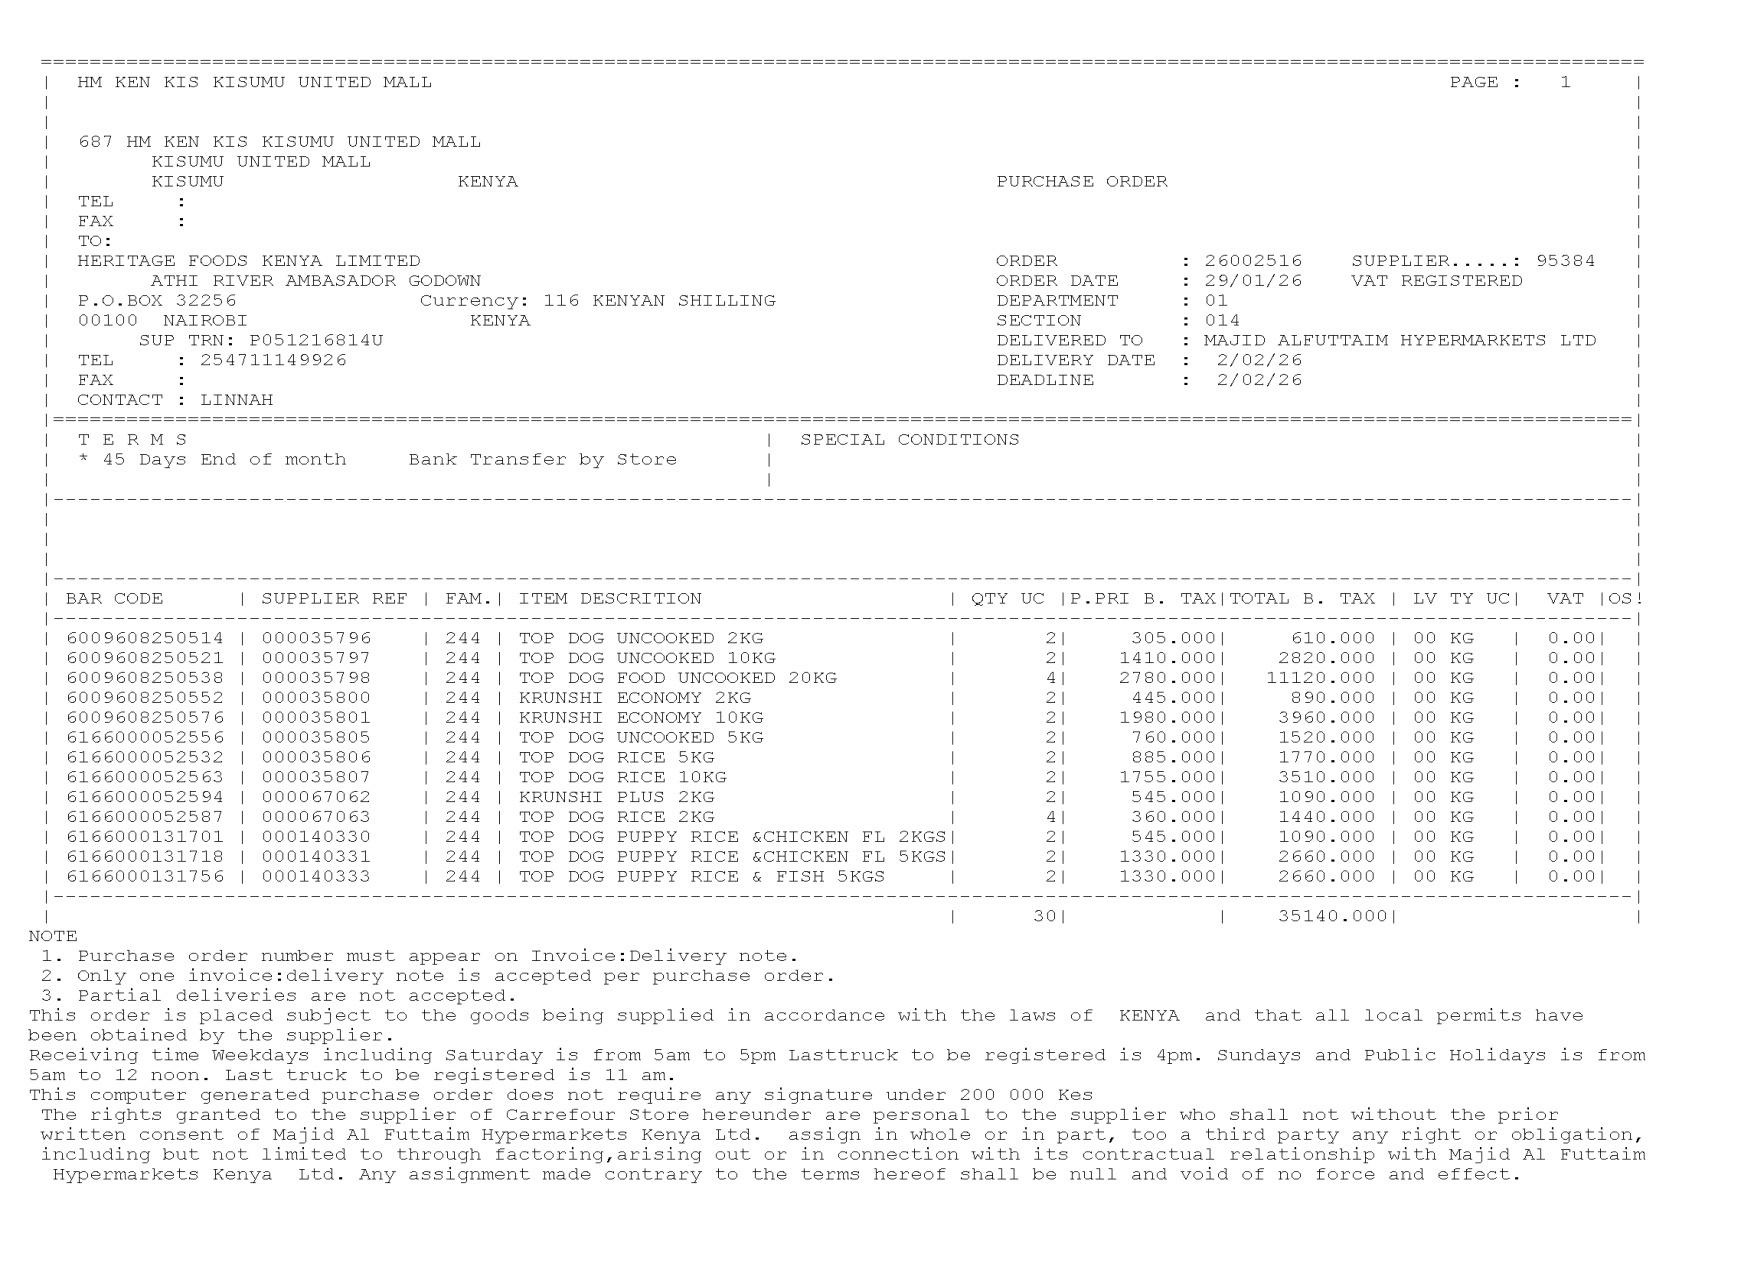

In [6]:
from IPython.display import display

display(po_sample["image"])

In [7]:
po_records = []

for item in load_dataset(
    "senga-ml/header_dataset_24_06",
    split="train",
    streaming=True
):
    data = json.loads(item["ground_truth"])

    header = data.get("gt_parse", {}).get("header", {})
    doc_type = header.get("document_type", "")

    if "PURCHASE ORDER" in doc_type.upper():
        po_records.append({
            "document_type": "purchase_order",
            "po_number": header.get("po_number"),
            "po_date": header.get("po_date"),
            "delivery_date": header.get("delivery_date"),
            "order_total": header.get("order_total"),
            "ground_truth": item["ground_truth"],
            "image": item["image"]
        })

print("PO records collected:", len(po_records))

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/senga-ml/header_dataset_24_06/resolve/2192ca709e6f653e89efb77b995c5ad6ff12a44b/data/train-00000-of-00001.parquet
Retrying in 1s [Retry 1/5].


PO records collected: 577


In [8]:
print(po_records[0].keys())

dict_keys(['document_type', 'po_number', 'po_date', 'delivery_date', 'order_total', 'ground_truth', 'image'])


In [9]:
print(po_records[0]["po_number"])
print(type(po_records[0]["image"]))

26002516
<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [10]:
print("Image size:", po_records[0]["image"].size)
print("Image mode:", po_records[0]["image"].mode)

Image size: (1754, 1271)
Image mode: RGB


In [11]:
for field in ["po_number", "po_date", "delivery_date", "order_total"]:
    missing = sum(
        1 for record in po_records
        if not record[field]
    )
    print(f"{field}: missing {missing} / {len(po_records)}")

po_number: missing 14 / 577
po_date: missing 10 / 577
delivery_date: missing 291 / 577
order_total: missing 213 / 577


In [12]:
fields_to_check = [
    "shipper_name",
    "shipper_address",
    "customer_name",
    "customer_address"
]

for field in fields_to_check:
    missing = 0

    for record in po_records:
        data = json.loads(record["ground_truth"])
        value = (
            data.get("gt_parse", {})
                .get("shipper", {})
                .get(field)
            if field.startswith("shipper_")
            else data.get("gt_parse", {})
                .get("customer", {})
                .get(field)
        )

        if not value:
            missing += 1

    print(f"{field}: missing {missing} / {len(po_records)}")

shipper_name: missing 82 / 577
shipper_address: missing 271 / 577
customer_name: missing 33 / 577
customer_address: missing 119 / 577


In [13]:
columns = [
    "document_id",
    "text",
    "label",
    "source"
]

df = pd.DataFrame(columns=columns)

print(df)
print(df.columns.tolist())

Empty DataFrame
Columns: [document_id, text, label, source]
Index: []
['document_id', 'text', 'label', 'source']


In [6]:
from datasets import load_dataset

enron = load_dataset(
    "corbt/enron-emails",
    split="train",
    streaming=True
)

email_records = []

for i, row in enumerate(enron):
    subject = row["subject"] or ""
    body = row["body"] or ""

    text = f"{subject}\n{body}".strip()

    if len(text) >= 200:
        email_records.append({
            "document_id": f"email_{len(email_records):04d}",
            "text": text,
            "label": "Email",
            "source": "Enron"
        })

    if len(email_records) >= 2000:
        break

email_df = pd.DataFrame(email_records)

print(email_df.shape)
print(email_df.head())

NameError: name 'pd' is not defined

In [15]:
print(email_df["text"].str.len().describe())
print()
print(email_df["label"].value_counts())
print()
print(email_df["source"].value_counts())

count     2000.000000
mean      1541.372000
std       2248.705343
min        206.000000
25%        436.000000
50%        808.500000
75%       1618.250000
max      39641.000000
Name: text, dtype: float64

label
Email    2000
Name: count, dtype: int64

source
Enron    2000
Name: count, dtype: int64


In [4]:
df = pd.concat([df, email_df], ignore_index=True)

print(df.shape)
print(df["label"].value_counts())

NameError: name 'pd' is not defined

In [17]:
contract_records = []

for i, item in enumerate(cuad_data["data"]):
    text = "\n".join(
        paragraph["context"]
        for paragraph in item["paragraphs"]
    ).strip()

    contract_records.append({
        "document_id": f"contract_{i:04d}",
        "text": text,
        "label": "Contract",
        "source": "CUAD"
    })

contract_df = pd.DataFrame(contract_records)

print(contract_df.shape)
print(contract_df.head())

NameError: name 'cuad_data' is not defined

In [18]:
from huggingface_hub import hf_hub_download
import json

cuad_json = hf_hub_download(
    repo_id="theatticusproject/cuad",
    repo_type="dataset",
    filename="CUAD_v1/CUAD_v1.json"
)

with open(cuad_json, "r", encoding="utf-8") as f:
    cuad_data = json.load(f)

print("Contracts:", len(cuad_data["data"]))

Contracts: 510


In [19]:
contract_records = []

for i, item in enumerate(cuad_data["data"]):
    text = "\n".join(
        paragraph["context"]
        for paragraph in item["paragraphs"]
    ).strip()

    contract_records.append({
        "document_id": f"contract_{i:04d}",
        "text": text,
        "label": "Contract",
        "source": "CUAD"
    })

contract_df = pd.DataFrame(contract_records)

print(contract_df.shape)
print(contract_df.head())

(510, 4)
     document_id                                               text     label  \
0  contract_0000  EXHIBIT 10.6\n\n                              ...  Contract   
1  contract_0001  Exhibit 10.26    CONFIDENTIAL TREATMENT HAS BE...  Contract   
2  contract_0002  Exhibit 10.16 SUPPLY CONTRACT Contract No: Dat...  Contract   
3  contract_0003  1                                             ...  Contract   
4  contract_0004  Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...  Contract   

  source  
0   CUAD  
1   CUAD  
2   CUAD  
3   CUAD  
4   CUAD  


In [20]:
print(contract_df["text"].str.len().describe())
print()
print(contract_df["label"].value_counts())
print()
print(contract_df["source"].value_counts())

count       510.000000
mean      52563.005882
std       55946.484865
min         645.000000
25%       16416.250000
50%       33143.000000
75%       66394.750000
max      338211.000000
Name: text, dtype: float64

label
Contract    510
Name: count, dtype: int64

source
CUAD    510
Name: count, dtype: int64


In [5]:
df = pd.concat([df, contract_df], ignore_index=True)

print(df.shape)
print()
print(df["label"].value_counts())

NameError: name 'pd' is not defined

In [22]:
import json
import zipfile
import pandas as pd

docile_zip = r"C:\Projects\DocuMind\data\docile\annotated-trainval.zip"

def extract_ocr_text(ocr_data):
    texts = []

    for page in ocr_data["pages"]:
        for block in page["blocks"]:
            for line in block["lines"]:
                line_text = " ".join(
                    word["value"] for word in line["words"]
                )
                texts.append(line_text)

    return "\n".join(texts)


invoice_records = []

with zipfile.ZipFile(docile_zip, "r") as z:

    train_meta = json.loads(z.read("train.json"))
    val_meta = json.loads(z.read("val.json"))

    all_ids = train_meta + val_meta

    for doc_id in all_ids:

        annotation = json.loads(
            z.read(f"annotations/{doc_id}.json")
        )

        if annotation["metadata"]["document_type"] != "tax_invoice":
            continue

        ocr_data = json.loads(
            z.read(f"ocr/{doc_id}.json")
        )

        text = extract_ocr_text(ocr_data).strip()

        if len(text) == 0:
            continue

        invoice_records.append({
            "document_id": f"invoice_{len(invoice_records):04d}",
            "text": text,
            "label": "Invoice",
            "source": "DocILE"
        })

        if len(invoice_records) >= 2000:
            break

invoice_df = pd.DataFrame(invoice_records)

print(invoice_df.shape)
print(invoice_df.head())

(2000, 4)
    document_id                                               text    label  \
0  invoice_0000  WIRE INSTRUCTIONS:\nNationsBank, N.A.\nBaltimo...  Invoice   
1  invoice_0001  Please Remit To:\nKMOZ 92.3 The Moose\n1360 E....  Invoice   
2  invoice_0002  UMI PUBLICATIONS, INC.\nP.O.BOX 30036 (28230)\...  Invoice   
3  invoice_0003  Page 1 of1\nINVOICE\nInvoice #\n2081683-1\nSta...  Invoice   
4  invoice_0004  Appud 10032089\nWAIT\nKLEN\nSAINISIC\nWalt Kle...  Invoice   

   source  
0  DocILE  
1  DocILE  
2  DocILE  
3  DocILE  
4  DocILE  


In [23]:
print(invoice_df["text"].str.len().describe())
print()
print(invoice_df["label"].value_counts())
print()
print(invoice_df["source"].value_counts())

count     2000.000000
mean      1652.782000
std       1546.917607
min        138.000000
25%        766.000000
50%       1159.500000
75%       1885.750000
max      17241.000000
Name: text, dtype: float64

label
Invoice    2000
Name: count, dtype: int64

source
DocILE    2000
Name: count, dtype: int64


In [3]:
df = pd.concat([df, invoice_df], ignore_index=True)

print(df.shape)
print()
print(df["label"].value_counts())

NameError: name 'pd' is not defined

In [25]:
po_records_clean = []

for i, record in enumerate(po_records):
    data = json.loads(record["ground_truth"])

    po_records_clean.append({
        "document_id": f"po_{i:04d}",
        "text": record["ground_truth"],
        "label": "Purchase Order",
        "source": "Senga PO"
    })

po_df = pd.DataFrame(po_records_clean)

print(po_df.shape)
print(po_df.head())

(577, 4)
  document_id                                               text  \
0     po_0000  {"gt_parse": {"header": {"document_type": "PUR...   
1     po_0001  {"gt_parse": {"header": {"document_type": "PUR...   
2     po_0002  {"gt_parse": {"header": {"document_type": "PUR...   
3     po_0003  {"gt_parse": {"header": {"document_type": "PUR...   
4     po_0004  {"gt_parse": {"header": {"document_type": "PUR...   

            label    source  
0  Purchase Order  Senga PO  
1  Purchase Order  Senga PO  
2  Purchase Order  Senga PO  
3  Purchase Order  Senga PO  
4  Purchase Order  Senga PO  


In [26]:
print(po_df["label"].value_counts())
print()
print(po_df["source"].value_counts())

label
Purchase Order    577
Name: count, dtype: int64

source
Senga PO    577
Name: count, dtype: int64


In [27]:
print(po_df["text"].str.len().describe())
print()
print(po_df["label"].value_counts())
print()
print(po_df["source"].value_counts())

count    577.000000
mean     495.781629
std      148.001164
min      111.000000
25%      400.000000
50%      504.000000
75%      618.000000
max      782.000000
Name: text, dtype: float64

label
Purchase Order    577
Name: count, dtype: int64

source
Senga PO    577
Name: count, dtype: int64


In [28]:
po_docile_records = []

with zipfile.ZipFile(docile_zip, "r") as z:

    train_meta = json.loads(z.read("train.json"))
    val_meta = json.loads(z.read("val.json"))

    all_ids = train_meta + val_meta

    for doc_id in all_ids:

        annotation = json.loads(
            z.read(f"annotations/{doc_id}.json")
        )

        if annotation["metadata"]["document_type"] != "purchase_order":
            continue

        ocr_data = json.loads(
            z.read(f"ocr/{doc_id}.json")
        )

        text = extract_ocr_text(ocr_data).strip()

        if len(text) == 0:
            continue

        po_docile_records.append({
            "document_id": f"po_{len(po_docile_records):04d}",
            "text": text,
            "label": "Purchase Order",
            "source": "DocILE"
        })

po_docile_df = pd.DataFrame(po_docile_records)

print(po_docile_df.shape)
print(po_docile_df.head())

(128, 4)
  document_id                                               text  \
0     po_0000  Neighborhood Research and Media\nPO BOX297\nRO...   
1     po_0001  Philip Morris US.A. BUSINESS\nPURCHASE REQUISI...   
2     po_0002  Philip Morris U.S.A. BUSINESS\nPURCHASE REQUIS...   
3     po_0003  Neighborhood Research and Media\nPO BOX297\nRO...   
4     po_0004  HISOADERNO\nSBMSUG INVOICE\n42520080\nPURCHASE...   

            label  source  
0  Purchase Order  DocILE  
1  Purchase Order  DocILE  
2  Purchase Order  DocILE  
3  Purchase Order  DocILE  
4  Purchase Order  DocILE  


In [29]:
print(po_docile_df["text"].str.len().describe())
print()
print(po_docile_df["label"].value_counts())
print()
print(po_docile_df["source"].value_counts())

count     128.000000
mean     1310.585938
std       670.954362
min       354.000000
25%       939.000000
50%      1207.500000
75%      1466.250000
max      5020.000000
Name: text, dtype: float64

label
Purchase Order    128
Name: count, dtype: int64

source
DocILE    128
Name: count, dtype: int64


In [30]:
df = pd.concat([df, po_docile_df], ignore_index=True)

print(df.shape)
print()
print(df["label"].value_counts())

(4638, 4)

label
Email             2000
Invoice           2000
Contract           510
Purchase Order     128
Name: count, dtype: int64


In [31]:
report_records = []

ledger = load_dataset(
    "artefactory/ledger-long-context-multi-kpi",
    "no_eval",
    split="dev",
    streaming=True
)

for row in ledger:
    text = row["mmd_text"]

    if not text:
        continue

    report_records.append({
        "document_id": f"report_{len(report_records):04d}",
        "text": text,
        "label": "Report",
        "source": "LEDGER"
    })

    if len(report_records) >= 2000:
        break

report_df = pd.DataFrame(report_records)

print(report_df.shape)
print(report_df.head())

(2000, 4)
   document_id                                               text   label  \
0  report_0000  ![](images/0_0.jpg)\n\n\n<--- Page Split --->\...  Report   
1  report_0001  \n## ANNUAL REPORT\n2021\n\n<--- Page Split --...  Report   
2  report_0002  \n## 88 ENERGY\nANNUAL REPORT\n2022\n\n<--- Pa...  Report   
3  report_0003  \n## 2012\nANNUAL REPORT\n\n![](images/0_0.jpg...  Report   
4  report_0004  ![](images/0_0.jpg)\n\n# Building\nTwo Great\n...  Report   

   source  
0  LEDGER  
1  LEDGER  
2  LEDGER  
3  LEDGER  
4  LEDGER  


In [32]:
print(report_df["text"].str.len().describe())
print()
print(report_df["label"].value_counts())
print()
print(report_df["source"].value_counts())

count    2.000000e+03
mean     5.589692e+05
std      3.471614e+05
min      3.180000e+02
25%      3.720280e+05
50%      4.965850e+05
75%      6.535165e+05
max      5.051046e+06
Name: text, dtype: float64

label
Report    2000
Name: count, dtype: int64

source
LEDGER    2000
Name: count, dtype: int64


In [33]:
df = pd.concat([df, report_df], ignore_index=True)

print(df.shape)
print()
print(df["label"].value_counts())

(6638, 4)

label
Email             2000
Invoice           2000
Report            2000
Contract           510
Purchase Order     128
Name: count, dtype: int64


In [34]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate document IDs:")
print(df["document_id"].duplicated().sum())

Missing values:
document_id    0
text           0
label          0
source         0
dtype: int64

Duplicate rows:
0

Duplicate document IDs:
0


In [35]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate document IDs:", df["document_id"].duplicated().sum())

Duplicate rows: 0
Duplicate document IDs: 0


In [36]:
class_summary = df.groupby("label")["text"].agg(
    documents="count",
    avg_length=lambda x: x.str.len().mean(),
    min_length=lambda x: x.str.len().min(),
    max_length=lambda x: x.str.len().max()
).sort_values("documents", ascending=False)

print(class_summary)

                documents     avg_length  min_length  max_length
label                                                           
Email                2000    1541.372000         206       39641
Report               2000  558969.201000         318     5051046
Invoice              2000    1652.782000         138       17241
Contract              510   52563.005882         645      338211
Purchase Order        128    1310.585938         354        5020


In [37]:
df["model_text"] = (
    df["text"]
    .str.replace(r'!\[.*?\]\(.*?\)', ' ', regex=True)
    .str.replace(r'<--- Page Split --->', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

df["model_text"] = df["model_text"].str.slice(0, 8000)

print(df[["label", "model_text"]].head())

   label                                         model_text
0  Email  Re: Traveling to have a business meeting takes...
1  Email  Please cc the following distribution list with...
2  Email  Re: High Speed Internet Access 1. login: palle...
3  Email  FW: fixed forward or other Collar floor gas pr...
4  Email  Re: FW: fixed forward or other Collar floor ga...


In [38]:
print(df["model_text"].str.len().describe())
print()
print(df.groupby("label")["model_text"].apply(lambda x: x.str.len().describe()))

count    6638.000000
mean     3921.391232
std      3349.719283
min       138.000000
25%       824.250000
50%      2002.000000
75%      8000.000000
max      8000.000000
Name: model_text, dtype: float64

label                
Contract        count     510.000000
                mean     7509.986275
                std      1501.842251
                min       645.000000
                25%      8000.000000
                50%      8000.000000
                75%      8000.000000
                max      8000.000000
Email           count    2000.000000
                mean     1395.508500
                std      1634.306586
                min       184.000000
                25%       422.000000
                50%       777.000000
                75%      1575.000000
                max      8000.000000
Invoice         count    2000.000000
                mean     1630.047000
                std      1411.633293
                min       138.000000
                25%       766.000000

In [39]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

ModuleNotFoundError: No module named 'sklearn'

In [40]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 4.2 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.3 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 2.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.8 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.9 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.7 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 3.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 4.0 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.3 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 4.1 MB/s  0:00:02
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.7 MB 9.6 MB/s eta 0:00:04
   --- --------------------

In [41]:
import sklearn

print(sklearn.__version__)

1.9.1


In [42]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (4646, 5)
Validation: (996, 5)
Test: (996, 5)


In [43]:
print("Train distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())

Train distribution:
label
Report            1400
Email             1400
Invoice           1400
Contract           357
Purchase Order      89
Name: count, dtype: int64

Validation distribution:
label
Invoice           300
Email             300
Report            300
Contract           76
Purchase Order     20
Name: count, dtype: int64

Test distribution:
label
Report            300
Invoice           300
Email             300
Contract           77
Purchase Order     19
Name: count, dtype: int64


In [44]:
X_train = train_df["model_text"]
y_train = train_df["label"]

X_val = val_df["model_text"]
y_val = val_df["label"]

X_test = test_df["model_text"]
y_test = test_df["label"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4646,)
(996,)
(996,)


In [45]:
from pathlib import Path

processed_dir = Path("../processed")
processed_dir.mkdir(exist_ok=True)

train_df[["document_id", "model_text", "label", "source"]].to_csv(
    processed_dir / "train.csv", index=False
)

val_df[["document_id", "model_text", "label", "source"]].to_csv(
    processed_dir / "validation.csv", index=False
)

test_df[["document_id", "model_text", "label", "source"]].to_csv(
    processed_dir / "test.csv", index=False
)

print("Datasets saved successfully.")

Datasets saved successfully.


In [2]:
full_corpus_df = df[
    ["document_id", "text", "label", "source"]
].copy()

print("Documents:", len(full_corpus_df))
print("Columns:", full_corpus_df.columns.tolist())
print("Maximum text length:", full_corpus_df["text"].str.len().max())

full_corpus_df.to_parquet(
    "../processed/full_corpus.parquet",
    index=False
)

print("Full corpus saved.")

NameError: name 'df' is not defined